<center>

# **`Build`** **`Transformer`** `from` **`Scratch`** `With` `Numpy only`
### **`Mechanism of Attention`**
### $$\text{Attention} = \text{softmax}\left(\frac{Q \cdot K^T}{\sqrt{d_\text{model}}}\right)$$
### **`Loss Function (Cross-Entropy)`**
### $$L = -\sum_{k=0}^{n} Y_k \cdot \ln(P_k)$$
### **`Gradient Descent`**
### $$W_{i+1} = W_i - \eta \cdot \frac{\partial L}{\partial W_i}$$

</center>

l'epoque 0 erreur est 1.8704757782408967  
l'epoque 400 erreur est 0.0068426282474732085  


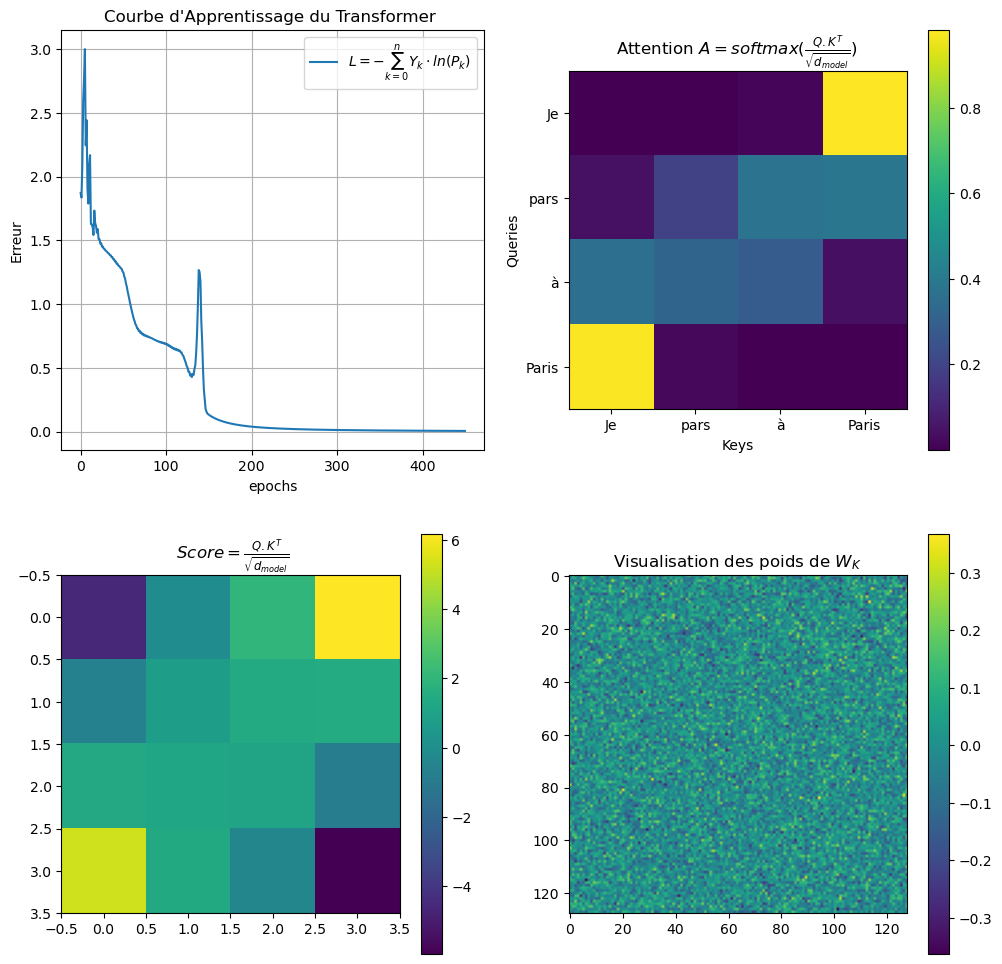

In [74]:
import numpy as np 
import matplotlib.pyplot as plt 

vocabular = {"je" : 0 , "pars" : 1 , "à" : 2 , "paris" : 3 , "la" : 4 
             ,"capitale" : 5 ,"de" : 6 , "france" : 7}

vocabular_list = ["je" , "pars" , "à" ,"paris" ]
phrase_lenght = len(vocabular_list)
list_numpy = [vocabular[word] for word in vocabular_list]
##### parametres du modele 
d_model = 128 
vocabular_size = len(vocabular)
xavier = np.sqrt(2/(2*d_model))

W_embedding = np.random.randn(vocabular_size , d_model)*xavier
W_q = np.random.randn(d_model , d_model)*xavier #(128 ,128)
W_k = np.random.randn(d_model , d_model)*xavier   
W_v = np.random.randn(d_model , d_model)*xavier 
W_final = np.random.randn(d_model , vocabular_size)*np.sqrt(2/(d_model+vocabular_size))

#### positional Embedding Matrixa
PE = np.zeros((phrase_lenght , d_model))
for pas in range(phrase_lenght): 
    for i in range(0 , d_model , 2): 
        n= 10000**(i/d_model)
        PE[pas ,i]=np.sin(pas/n)
        PE[pas ,i+1]=np.cos(pas/n)
        
### softmax funcion 
def softmax(x): 
    x_norm = x -np.max(x ,axis=-1 ,keepdims=True)
    exp_x = np.exp(x_norm)
    probabilities  = exp_x /np.sum(exp_x , axis=-1 ,keepdims=True)
    return probabilities

### matrice one Hot encoding
Y_true = np.zeros((phrase_lenght ,vocabular_size))
## taille (4 ,8)
for t , word_index in enumerate(list_numpy): 
    Y_true[t ,word_index] = 1.0
#print(f"Y_true" , Y_true)
list_epochs = [ ]
list_loss   = [ ]

epochs = 450
lr = 0.1

for i in range(epochs): 
    
    ## Embedding X de taille (4 ,128)
    X_embedding = W_embedding[list_numpy]
    X = X_embedding + PE 
    ## Query ,Value and Key Q ,V et K
    Q = X @ W_q # taille de (4 ,128) Q , K and V
    V = X @ W_v 
    K = X @ W_k
    ## calcul du score 
    score = (Q @ K.T)/np.sqrt(d_model)
    ### Calcul de l'Attention A = attention
    A = softmax(score)
    ## calcul de la somme ponderee pour l'attention qui est Z_0
    Z_0 = A @ V ## dimension (4 ,128)
    logits = Z_0 @ W_final
    ### on applique softmax sur logits p0ur transformer logits 
    ### en probabilites donc on calcule la probabilites de chaque mot du dictionnaire donc la
    ### variable "vocabular"
    probs = softmax(logits)
    ### Calclus des gradients 
    ## derive de L / logits
    dlogits = (probs-Y_true) / phrase_lenght
    ## derive de L par rapport W_final
    dW_final = Z_0.T @ dlogits
    ## derive de L / a Z_0 
    dZ_0 = dlogits @ W_final.T # (4,128)
    ## derive  de L / a V 
    dV = softmax(score).T @ dZ_0
    ## derivee de L / a A 
    dA = dZ_0 @ V.T 
    ## derivee de L / a score
    dscore = A*(dA - np.sum(dA*A ,axis=-1 ,keepdims=True))
    ## derives de L / a Q et,K 
    dQ = (dscore @ K)/np.sqrt(d_model)
    dK = (dscore.T @ Q)/np.sqrt(d_model)
    ## derives de L / a dW_q et,dW_k 
    dW_q = X.T @ dQ
    dW_k = X.T @ dK
    dW_v = X.T @ dV
    ## derive de L / a X  
    dX = dQ @ W_q.T + dK @ W_k.T + dV @ W_v.T
    ## mise a jors des parametres 
    W_k -= lr*dW_k
    W_q -= lr*dW_q
    W_v -= lr*dW_v
    W_final -= lr*dW_final
    W_embedding[list_numpy] -= lr*dX
    ### affichage courbe d'apprentisage & calcul de l'erreur 
    loss = - np.sum(Y_true*np.log(probs + 1e-9) )/phrase_lenght
    loss_iteration = 0 
    loss_iteration += loss 
    list_loss.append(loss_iteration)
    list_epochs.append(i)
    if i % 400 == 0 : 
        print(f"l'epoque {i} erreur est {list_loss[i]}  "  )
       
plt.figure(figsize=(12 ,12))
plt.subplot(2 ,2 ,1)
plt.title(r"Courbe d'Apprentissage du Transformer ")
plt.plot(list_epochs ,list_loss , label=r'$L=-\sum_{k=0}^{n} Y_k \cdot ln(P_k) $')
plt.xlabel('epochs')
plt.ylabel('Erreur')
plt.legend()
plt.grid()

plt.subplot(2 ,2 ,2)
plt.imshow(A, cmap='viridis')
plt.colorbar()
tokens = ["Je", "pars", "à", "Paris"]
# On définit les positions (0, 1, 2, 3)
positions = range(len(tokens))
# On remplace les chiffres par les mots sur l'axe X (horizontal)
plt.xticks(positions, tokens)
# On remplace les chiffres par les mots sur l'axe Y (vertical)
plt.yticks(positions, tokens)
plt.title(r"Attention $A=softmax(\frac{Q.K^T}{\sqrt{d_{model}}}) $ ")
plt.xlabel("Keys")
plt.ylabel("Queries")

plt.subplot(2 ,2 ,3)
plt.imshow(score , cmap='viridis')
plt.colorbar()
plt.title(r" $Score=\frac{Q.K^T}{\sqrt{d_{model}}}$")

plt.subplot(2 ,2 ,4)
plt.imshow(W_k, cmap='viridis')
plt.colorbar()
plt.title("Visualisation des poids de $W_K$") 

plt.show()
